Cell 1 - Install Libraries

In [11]:
pip install yfinance pandas numpy matplotlib seaborn mplfinance plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Cell 2 - Import Libraries

In [35]:
tickers = input("Enter ticker(s) separated by comma (Example: AAPL,TSLA,BTC-USD): ")
period = input("Enter time period (1d,5d,1mo,6mo,1y,max): ")
interval = input("Enter interval (1m,5m,1h,1d): ")


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf

Cell 3 Market symbols

In [33]:
# NIFTY 50 Stocks
nifty50 = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS"
]

# BANK NIFTY
banknifty = [
"HDFCBANK.NS","ICICIBANK.NS","SBIN.NS",
"AXISBANK.NS","KOTAKBANK.NS","INDUSINDBK.NS"
]

# US Stocks
us_stocks = [
"AAPL","MSFT","TSLA","NVDA","AMZN","GOOGL",
"META","AMD","INTC","NFLX"
]

# Top 20 Crypto
crypto = [
"BTC-USD","ETH-USD","BNB-USD","XRP-USD","SOL-USD",
"ADA-USD","DOGE-USD","TRX-USD","DOT-USD","MATIC-USD",
"LTC-USD","SHIB-USD","AVAX-USD","LINK-USD","XLM-USD",
"ATOM-USD","APT-USD","ARB-USD","NEAR-USD","FIL-USD"
]

# Forex Pairs
forex = [
"USDINR=X","USDCAD=X","USDJPY=X","USDAUD=X",
"USDKRW=X","GBPUSD=X","EURUSD=X"
]

# Commodities
commodities = [
"GC=F", # Gold
"SI=F", # Silver
"HG=F"  # Copper
]

Cell -4 Download Market data

In [40]:
data = yf.download(
    tickers.split(","),
    period=period,
    interval=interval
)

close_prices = data["Close"]
close_prices.head()

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2025-09-03,111723.210938
2025-09-04,110723.601562
2025-09-05,110650.984375
2025-09-06,110224.695312
2025-09-07,111167.617188


Cell 5 – Data Cleaning

In [41]:
df = close_prices.dropna(axis=1, how="all")

returns = df.pct_change().dropna()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (182, 1)


Ticker,BTC-USD
Date,
2025-09-03,111723.210938
2025-09-04,110723.601562
2025-09-05,110650.984375
2025-09-06,110224.695312
2025-09-07,111167.617188


Cell 6 – Returns Calculations

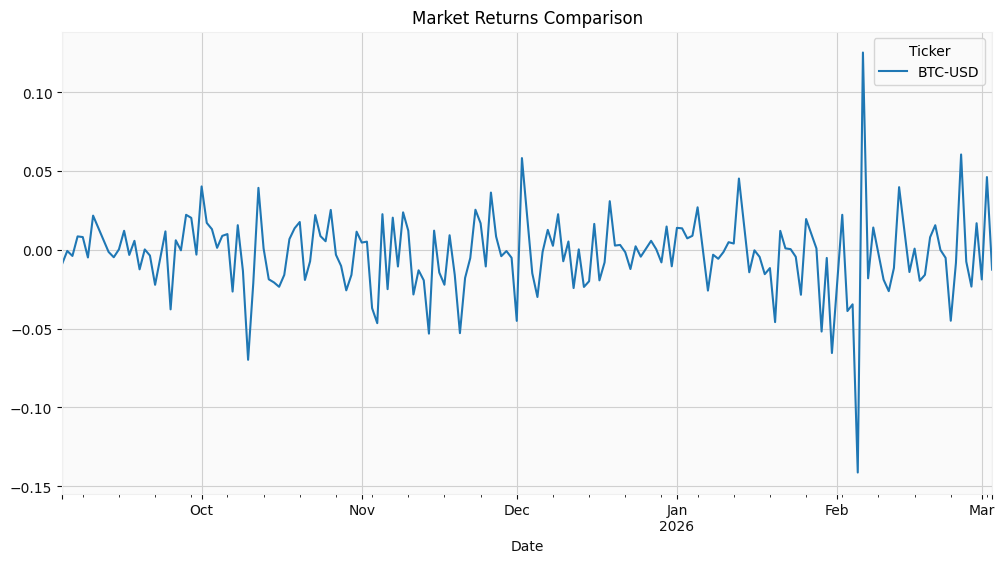

In [42]:
returns.plot(figsize=(12,6))

plt.title("Market Returns Comparison")

plt.savefig("visualizations/charts/returns.png")

plt.show()

<Figure size 1400x700 with 0 Axes>

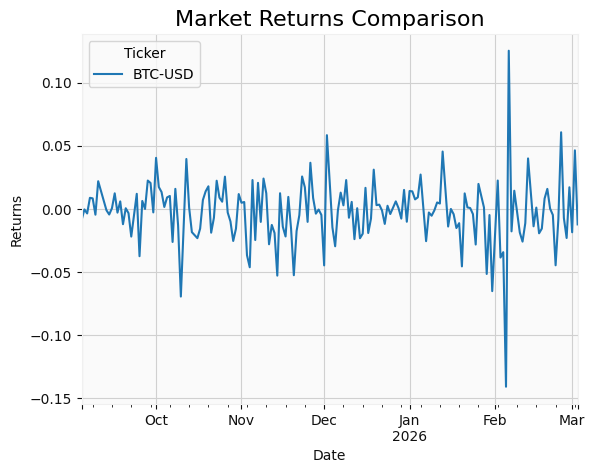

In [43]:
# Returns Visualization Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

returns.plot()

plt.title("Market Returns Comparison", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Returns")

plt.grid(True)

# Save image
plt.savefig("visualizations/charts/returns.png")

plt.show()

In [52]:
symbol = input("Enter symbol (Example: TSLA, AAPL, BTC-USD, RELIANCE.NS, EURUSD=X): ")

candlestick_data = yf.download(symbol, period="3mo", interval="1d")

candlestick_data = candlestick_data[["Open","High","Low","Close","Volume"]]
candlestick_data = candlestick_data.astype(float)
candlestick_data = candlestick_data.dropna()

from datetime import datetime
import os

os.makedirs("visualizations/charts/candlesticks", exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

filename = f"visualizations/charts/candlesticks/{symbol}_candlestick_{timestamp}.png"

mpf.plot(
    candlestick_data,
    type="candle",
    style="yahoo",
    volume=True,
    title=f"{symbol} Candlestick Chart",
    ylabel="Price",
    ylabel_lower="Volume",
    savefig=filename
)

print("Chart saved at:", filename)


[*********************100%***********************]  1 of 1 completed


ValueError: Data for column "Open" must be ALL float or int.

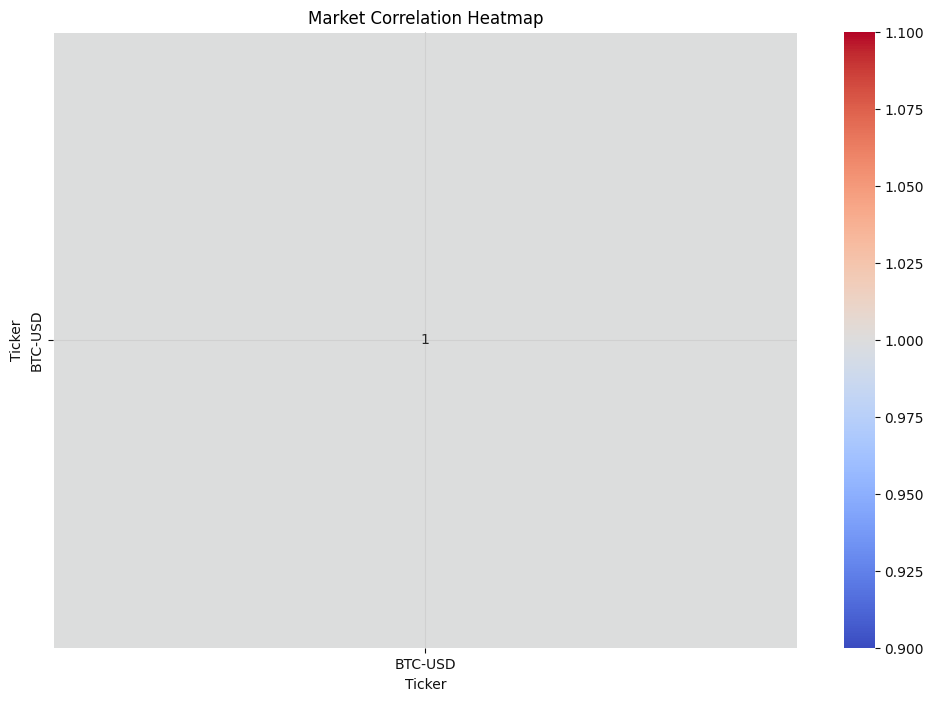

In [46]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Market Correlation Heatmap")

# Save image
plt.savefig("visualizations/charts/heatmap.png")

plt.show()

Cell 7 – Stastial Analysis

In [51]:
df[["AAPL","BTC-USD","RELIANCE.NS"]].plot(figsize=(12,6))
plt.title("Market Trend Comparison")
plt.show()

KeyError: "['AAPL', 'RELIANCE.NS'] not in index"

Cell 8 – Visualisation

In [ ]:
import yfinance as yf
import plotly.graph_objects as go
import pandas as pd

# ================================
# MARKET SYMBOLS
# ================================

# 🇮🇳 NIFTY 50 Stocks
nifty50 = [
"RELIANCE.NS","TCS.NS","HDFCBANK.NS","ICICIBANK.NS","INFY.NS",
"HINDUNILVR.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","KOTAKBANK.NS",
"LT.NS","AXISBANK.NS","ASIANPAINT.NS","MARUTI.NS","SUNPHARMA.NS",
"TITAN.NS","ULTRACEMCO.NS","BAJFINANCE.NS","NESTLEIND.NS","HCLTECH.NS"
]

# 🇮🇳 BANK NIFTY Stocks
banknifty = [
"HDFCBANK.NS","ICICIBANK.NS","SBIN.NS","KOTAKBANK.NS",
"AXISBANK.NS","INDUSINDBK.NS","BANDHANBNK.NS","IDFCFIRSTB.NS",
"FEDERALBNK.NS","PNB.NS","BANKBARODA.NS","AUBANK.NS"
]

# 🇺🇸 Top US Stocks
us_stocks = [
"AAPL","MSFT","AMZN","GOOGL","META",
"TSLA","NVDA","JPM","V","WMT",
"PG","DIS","NFLX","ADBE","INTC"
]

# 🪙 Top 20 Crypto
crypto = [
"BTC-USD","ETH-USD","BNB-USD","SOL-USD","XRP-USD",
"ADA-USD","DOGE-USD","AVAX-USD","TRX-USD","DOT-USD",
"MATIC-USD","LTC-USD","BCH-USD","LINK-USD","ATOM-USD",
"ETC-USD","FIL-USD","APT-USD","NEAR-USD","ICP-USD"
]

# 💱 Forex Pairs
forex = [
"USDINR=X","USDCAD=X","USDJPY=X","USDKRW=X",
"AUDUSD=X","GBPUSD=X","EURUSD=X"
]

# 🪙 Commodities
commodities = [
"GC=F",   # Gold
"SI=F",   # Silver
"HG=F",   # Copper
"CL=F"    # Crude Oil
]

# Combine all symbols
symbols = nifty50 + banknifty + us_stocks + crypto + forex + commodities

print("Total Symbols:", len(symbols))

# ================================
# DOWNLOAD DATA
# ================================

symbol = "AAPL"  # Change this to any symbol

data = yf.download(symbol, period="6mo", interval="1d")

# ================================
# CANDLESTICK CHART
# ================================

fig = go.Figure(data=[go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
)])

fig.update_layout(
    title=f"{symbol} Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False
)

fig.show()

Cell 8 – Heatmap

In [ ]:
returns = data['Close'].pct_change()

corr = returns.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.savefig("visualizations/charts/heatmap.png")
plt.show()

Cell 9 Candlestick Charts

In [50]:
symbol = input("Enter symbol (Example: TSLA, AAPL, BTC-USD, RELIANCE.NS, EURUSD=X): ")

candlestick_data = yf.download(symbol, period="3mo", interval="1d")

candlestick_data = candlestick_data[["Open","High","Low","Close","Volume"]]
candlestick_data = candlestick_data.astype(float)
candlestick_data = candlestick_data.dropna()

from datetime import datetime
import os

os.makedirs("visualizations/charts/candlesticks", exist_ok=True)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

filename = f"visualizations/charts/candlesticks/{symbol}_candlestick_{timestamp}.png"

mpf.plot(
    candlestick_data,
    type="candle",
    style="yahoo",
    volume=True,
    title=f"{symbol} Candlestick Chart",
    ylabel="Price",
    ylabel_lower="Volume",
    savefig=filename
)

print("Chart saved at:", filename)

[*********************100%***********************]  1 of 1 completed


ValueError: Data for column "Open" must be ALL float or int.

Cell 10 – Portofolio risk Calculator


In [ ]:
import numpy as np

# Example portfolio assets
portfolio_assets = [
"AAPL",
"MSFT",
"RELIANCE.NS",
"BTC-USD",
"ETH-USD"
]

# Portfolio allocation
weights = np.array([0.2,0.2,0.2,0.2,0.2])

data = yf.download(portfolio_assets, period="1y")['Close']

returns = data.pct_change()

mean_returns = returns.mean()

cov_matrix = returns.cov()

portfolio_return = np.sum(mean_returns * weights) * 252

portfolio_volatility = np.sqrt(np.dot(weights.T,np.dot(cov_matrix*252,weights)))

sharpe_ratio = portfolio_return / portfolio_volatility

print("Expected Annual Return:",portfolio_return)
print("Portfolio Risk:",portfolio_volatility)
print("Sharpe Ratio:",sharpe_ratio)

Cell 11 – PnL Calculator

In [ ]:
investment = 100000   # INR or USD

symbol = "BTC-USD"

data = yf.download(symbol,period="1y")

buy_price = data['Close'].iloc[0]
current_price = data['Close'].iloc[-1]

quantity = investment / buy_price

current_value = quantity * current_price

pnl = current_value - investment

print("Investment:",investment)
print("Buy Price:",buy_price)
print("Current Price:",current_price)
print("Current Value:",current_value)
print("Profit / Loss:",pnl)

Cell 12 - Heatmap correlation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

assets = [
"AAPL",
"MSFT",
"RELIANCE.NS",
"BTC-USD",
"ETH-USD",
"USDINR=X",
"GC=F"
]

data = yf.download(assets,period="1y")['Close']

returns = data.pct_change()

correlation = returns.corr()

plt.figure(figsize=(10,6))

sns.heatmap(correlation,annot=True,cmap="coolwarm")

plt.title("Market Correlation Heatmap")

plt.show()

Cell 13 — Portfolio Performance Summary

In [ ]:
summary = pd.DataFrame()

summary['Mean Return'] = returns.mean()

summary['Volatility'] = returns.std()

summary['Sharpe'] = summary['Mean Return'] / summary['Volatility']

summary.sort_values(by="Sharpe",ascending=False)